In [1]:
import os, random
import numpy as np
from glob import glob
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import defaultdict, Counter

# 🔥 reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
# Lymphoma
CLL_PATH = "/kaggle/input/datasets/andrewmvd/malignant-lymphoma-classification/CLL"
FL_PATH  = "/kaggle/input/datasets/andrewmvd/malignant-lymphoma-classification/FL"
MCL_PATH = "/kaggle/input/datasets/andrewmvd/malignant-lymphoma-classification/MCL"

# Leukemia
ALL_PATH = "/kaggle/input/datasets/priyaadharshinivs062/leukemia-dataset/train/train/all train/all train"
AML_PATH = "/kaggle/input/datasets/priyaadharshinivs062/leukemia-dataset/train/train/aml train/aml train"
CLL_LEUK_PATH = "/kaggle/input/datasets/priyaadharshinivs062/leukemia-dataset/train/train/cll train/cll train"
CML_PATH = "/kaggle/input/datasets/priyaadharshinivs062/leukemia-dataset/train/train/cml/cml"

# Healthy
HEALTHY_PATH = "/kaggle/input/datasets/priyaadharshinivs062/leukemia-dataset/train/train/h train/h train"

# Myeloma
MYELOMA_TRAIN = "/kaggle/input/datasets/sbilab/segpc2021dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/train/train/train/x"
MYELOMA_VAL   = "/kaggle/input/datasets/sbilab/segpc2021dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/TCIA_SegPC_dataset/validation/validation/x"

In [3]:
def get_imgs(path):
    return (
        glob(path + "/**/*.jpg", recursive=True) +
        glob(path + "/**/*.png", recursive=True) +
        glob(path + "/**/*.tif", recursive=True) +
        glob(path + "/**/*.bmp", recursive=True)
    )

leukemia_imgs = get_imgs(ALL_PATH) + get_imgs(AML_PATH) + get_imgs(CLL_LEUK_PATH) + get_imgs(CML_PATH)
healthy_imgs = get_imgs(HEALTHY_PATH)
lymphoma_imgs = get_imgs(CLL_PATH) + get_imgs(FL_PATH) + get_imgs(MCL_PATH)

myel_train = get_imgs(MYELOMA_TRAIN)
myel_val   = get_imgs(MYELOMA_VAL)

print(len(leukemia_imgs), len(lymphoma_imgs), len(myel_train), len(healthy_imgs))

12000 374 298 3000


In [4]:
def get_patient_id(path):
    return os.path.basename(path).split("_")[0]

def patient_split(imgs, test_size=0.2):
    groups = defaultdict(list)

    for img in imgs:
        pid = get_patient_id(img)
        groups[pid].append(img)

    pids = list(groups.keys())
    random.shuffle(pids)

    split = int(len(pids)*(1-test_size))

    train_ids = pids[:split]
    val_ids   = pids[split:]

    train_imgs, val_imgs = [], []

    for pid in train_ids:
        train_imgs.extend(groups[pid])

    for pid in val_ids:
        val_imgs.extend(groups[pid])

    return train_imgs, val_imgs

In [5]:
leuk_train, leuk_val = patient_split(leukemia_imgs)
lymph_train, lymph_val = patient_split(lymphoma_imgs)
health_train, health_val = patient_split(healthy_imgs)

In [6]:
lymph_train = lymph_train * 4
myel_train  = myel_train * 2

In [7]:
train_data, val_data = [], []

# TRAIN
for img in leuk_train: train_data.append((img,0))
for img in lymph_train: train_data.append((img,1))
for img in myel_train: train_data.append((img,2))
for img in health_train: train_data.append((img,3))

# VAL
for img in leuk_val: val_data.append((img,0))
for img in lymph_val: val_data.append((img,1))
for img in myel_val: val_data.append((img,2))
for img in health_val: val_data.append((img,3))

random.shuffle(train_data)
random.shuffle(val_data)

print("Train:", Counter([y for _,y in train_data]))
print("Val:", Counter([y for _,y in val_data]))

Train: Counter({0: 11223, 3: 2701, 1: 1224, 2: 596})
Val: Counter({0: 777, 3: 299, 2: 200, 1: 68})


In [8]:
class BloodDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        path, label = self.data[idx]

        try:
            img = Image.open(path).convert("RGB")
        except:
            return self.__getitem__((idx+1) % len(self.data))

        if self.transform:
            img = self.transform(img)

        return img, label

In [9]:
train_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(35),
    transforms.ColorJitter(0.5,0.5,0.5),
    transforms.RandomResizedCrop(224, scale=(0.6,1.0)),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [10]:
train_labels = [y for _,y in train_data]
class_counts = np.bincount(train_labels)
weights = 1. / class_counts

sample_weights = [weights[label] for label in train_labels]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(BloodDataset(train_data, train_tfms),
                          batch_size=32, sampler=sampler)

val_loader = DataLoader(BloodDataset(val_data, val_tfms),
                        batch_size=32, shuffle=False)

In [11]:
model = models.efficientnet_b0(weights="IMAGENET1K_V1")
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 4)

for param in model.features.parameters():
    param.requires_grad = False

model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 142MB/s] 


In [12]:
weights = torch.tensor([1.0, 4.0, 1.8, 1.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

In [13]:
epochs = 10
best_val_loss = float("inf")
counter = 0

for epoch in range(epochs):

    model.train()
    train_loss, correct, total = 0, 0, 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Train"):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = correct / total

    model.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} Val"):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    scheduler.step()

    # Unfreeze
    if epoch == 3:
        print("🔓 Unfreezing backbone")
        for p in model.features.parameters():
            p.requires_grad = True
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1
        if counter >= 3:
            print("⛔ Early stopping")
            break

Epoch 1 Val: 100%|██████████| 42/42 [03:58<00:00,  5.67s/it]



Epoch 1
Train Loss: 0.4599 | Train Acc: 0.8482
Val   Loss: 0.3057 | Val   Acc: 0.9360


Epoch 2 Val: 100%|██████████| 42/42 [02:56<00:00,  4.19s/it]



Epoch 2
Train Loss: 0.1261 | Train Acc: 0.9595
Val   Loss: 0.1598 | Val   Acc: 0.9955


Epoch 3 Val: 100%|██████████| 42/42 [02:58<00:00,  4.26s/it]


...


Epoch 8
Train Loss: 0.0069 | Train Acc: 0.9972
Val   Loss: 0.0359 | Val   Acc: 0.9985


Epoch 9 Val: 100%|██████████| 42/42 [03:00<00:00,  4.29s/it]



Epoch 9
Train Loss: 0.0040 | Train Acc: 0.9987
Val   Loss: 0.0139 | Val   Acc: 0.9985


Epoch 10 Val: 100%|██████████| 42/42 [02:58<00:00,  4.26s/it]


Epoch 10
Train Loss: 0.0026 | Train Acc: 0.9990
Val   Loss: 0.0132 | Val   Acc: 0.9993


In [14]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("Accuracy:", np.mean(np.array(all_preds)==np.array(all_labels)))

Accuracy: 0.9992559523809523


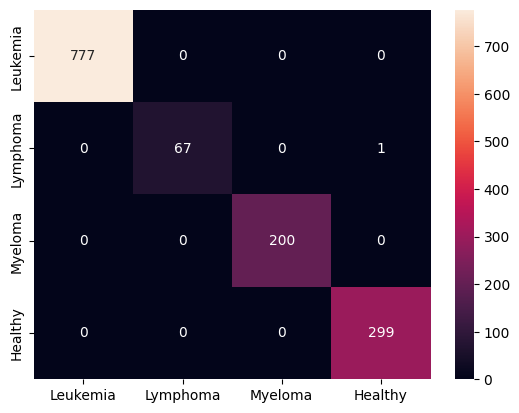

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       777
           1     1.0000    0.9853    0.9926        68
           2     1.0000    1.0000    1.0000       200
           3     0.9967    1.0000    0.9983       299

    accuracy                         0.9993      1344
   macro avg     0.9992    0.9963    0.9977      1344
weighted avg     0.9993    0.9993    0.9993      1344



In [15]:
labels = ["Leukemia","Lymphoma","Myeloma","Healthy"]

cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=labels,
            yticklabels=labels)
plt.show()

print(classification_report(all_labels, all_preds, digits=4))